# vbOCP — Test 1: pipeline completa

Notebook orchestratore bash-style: le celle di codice lanciano solo comandi verso gli script della repo — nessuna logica del modello qui dentro. Stesso pattern per Colab/cluster: cambia solo dove lo lanci.

**Contenuto:**
1. Setup (path della repo)
2. FOM — solve singolo + plot, generazione snapshot
3. ROM (POD) — training + plot decadimento autovalori
4. GNN *(da aggiungere)*
5. Autoencoder *(da aggiungere)*

## 1. Setup

In [4]:
import os

# si sposta nella root della repo (dove c'e' src/), indipendentemente da dove parte il kernel
while not os.path.isdir('src') and os.getcwd() != os.path.dirname(os.getcwd()):
    os.chdir('..')
assert os.path.isdir('src'), "src/ non trovata: verifica dove e' montata la repo vbOCP"

REPO_ROOT      = os.getcwd()
CONFIG_PATH    = os.path.join('configs', 'test1.yaml')
DATA_DIR       = os.path.join('data')
SNAPSHOTS_DIR  = os.path.join('data', 'snapshots')
OUTPUT_DIR     = os.path.join('notebooks', 'output')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SNAPSHOTS_DIR, exist_ok=True)

print('REPO_ROOT    :', REPO_ROOT)
print('CONFIG_PATH  :', CONFIG_PATH)
print('SNAPSHOTS_DIR:', SNAPSHOTS_DIR)

REPO_ROOT    : /shared/vbOCP
CONFIG_PATH  : configs/test1.yaml
SNAPSHOTS_DIR: data/snapshots


## 2. FOM

### 2.1 Solve singolo + plot

Risolve il FOM per una terna di parametri e salva un confronto visivo di stato `y` e aggiunto `p`. Modifica `--mu1`/`--mu2`/`--mu_u` per esplorare altri punti dello spazio parametrico.

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Nh = 5306
Assembly operatori (indipendenti da mu) ...
Assembly matrice di controllo C(mu_u=0.99) ...
Solve OTD per mu1=12.0, mu2=2.5, mu_u=0.99 ...
Soluzione OTD:
  stato     y: min=1.0000, max=6.9002
  aggiunto  p: min=0.0005, max=1.4058
  controllo u: min=0.0075, max=20.0831
Plot salvato in /tmp/fom_solution.png
PLOT_PATH=/tmp/fom_solution.png


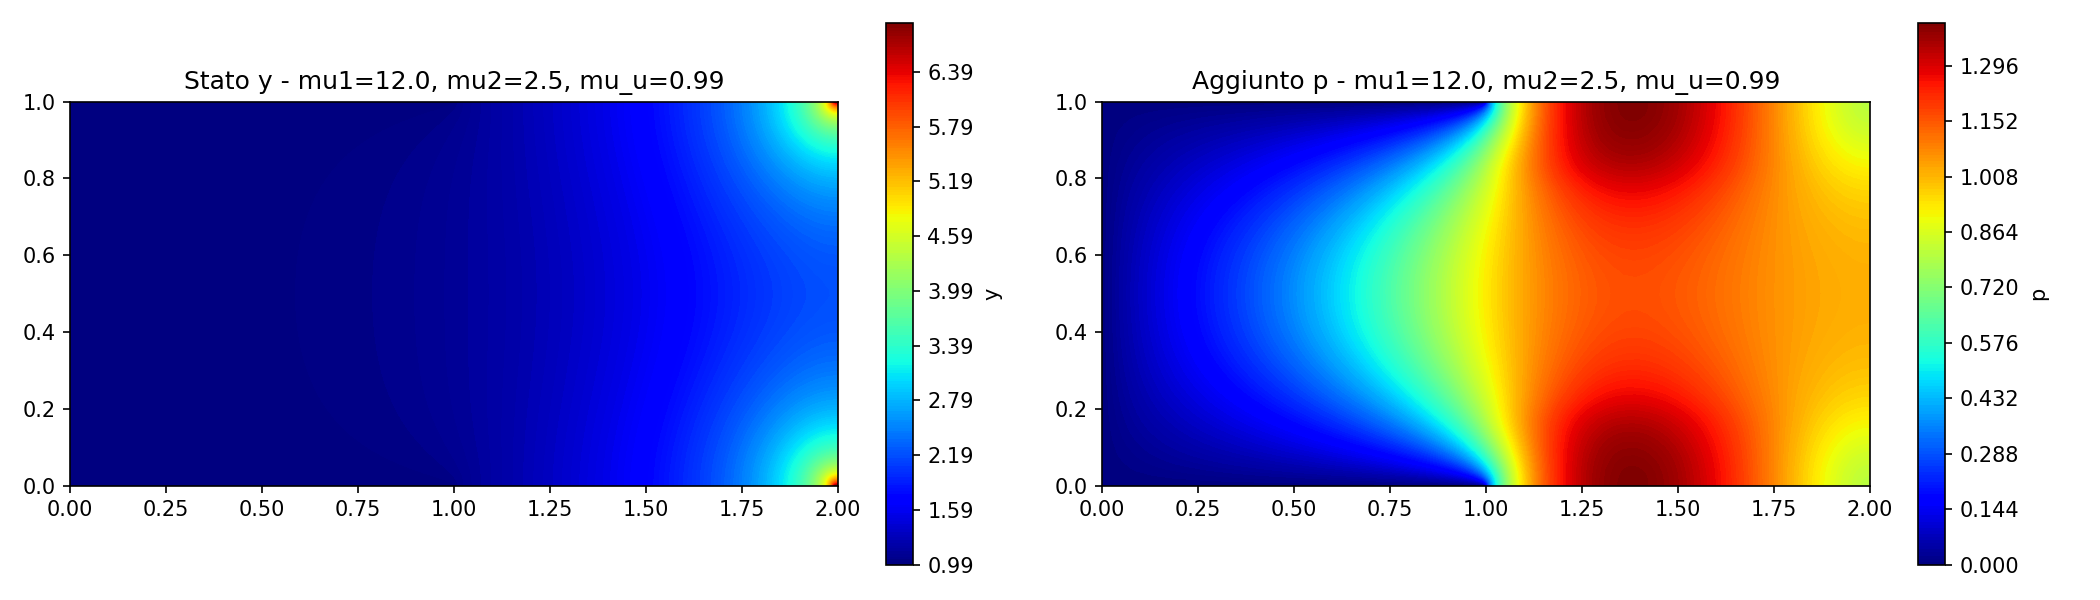

In [5]:
!python -m src.full_order.run_single_solve \
    --config {CONFIG_PATH} \
    --mu1 12 \
    --mu2 2.5 \
    --mu_u 0.99 \
    --plot

import tempfile, os as _os
from IPython.display import Image
Image(_os.path.join(tempfile.gettempdir(), 'fom_solution.png'))

### 2.2 Generazione snapshot (training + test)

Campiona `mu1`, `mu2`, `mu_u` uniformemente sui range definiti nel config e risolve il FOM per ciascun campione. L'assembly indipendente da mu viene fatto una sola volta; il ciclo aggiorna solo la matrice di controllo e il solve.

Due set separati (seed diversi): uno di **training** (per la POD) e uno di **test** (mai visto durante la POD, per validare il ROM). Se un file esiste gia', **non viene rigenerato** (skip).

Output: un `.npz` per set, con `mu1`, `mu2`, `mu_u`, e le matrici `Y`, `P`, `U` (una colonna per campione).

In [6]:
N_SAMPLES = 300
N_TEST = 150
TEST_SEED = 123  # diverso dal seed di default usato per il training (42)

SNAPSHOTS_PATH = os.path.join(SNAPSHOTS_DIR, f'test1_{N_SAMPLES}.npz')
TEST_SNAPSHOTS_PATH = os.path.join(SNAPSHOTS_DIR, f'test1_test{N_TEST}.npz')

if os.path.exists(SNAPSHOTS_PATH):
    print(f"Training set gia' presente: {SNAPSHOTS_PATH} (skip)")
else:
    !python -m src.full_order.generate_snapshots \
        --config {CONFIG_PATH} \
        --n-samples {N_SAMPLES} \
        --output {SNAPSHOTS_PATH}

if os.path.exists(TEST_SNAPSHOTS_PATH):
    print(f"Test set gia' presente: {TEST_SNAPSHOTS_PATH} (skip)")
else:
    !python -m src.full_order.generate_snapshots \
        --config {CONFIG_PATH} \
        --n-samples {N_TEST} \
        --seed {TEST_SEED} \
        --output {TEST_SNAPSHOTS_PATH}

Training set gia' presente: data/snapshots/test1_300.npz (skip)
Test set gia' presente: data/snapshots/test1_test150.npz (skip)


In [7]:
import numpy as np

data = np.load(SNAPSHOTS_PATH)
print('Training - chiavi:', list(data.keys()), ' Y shape:', data['Y'].shape)

test_data = np.load(TEST_SNAPSHOTS_PATH)
print('Test     - chiavi:', list(test_data.keys()), ' Y shape:', test_data['Y'].shape)

Training - chiavi: ['mu1', 'mu2', 'mu_u', 'Y', 'P', 'U']  Y shape: (5306, 300)
Test     - chiavi: ['mu1', 'mu2', 'mu_u', 'Y', 'P', 'U']  Y shape: (5306, 150)


## 3. ROM (POD)

### 3.1 Stato e aggiunto

Costruisce la base POD per stato e aggiunto a partire dagli snapshot generati sopra. Il numero di modi N e' scelto automaticamente in base a una soglia di energia cumulata (non piu' fisso). Prodotto scalare configurabile qui sotto; `--plot` mostra subito il decadimento degli autovalori (nessun path da gestire).

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Prodotto scalare: seminorm
Caricamento snapshot da data/snapshots/test1_300.npz ...
Y shape: (5306, 300), P shape: (5306, 300)
N scelto: stato=71, aggiunto=18 -> uso N=71 per entrambi
Base POD salvata in data/snapshots/test1_pod.npz
Plot salvato in /tmp/pod_eigenvalue_decay.png
PLOT_PATH=/tmp/pod_eigenvalue_decay.png


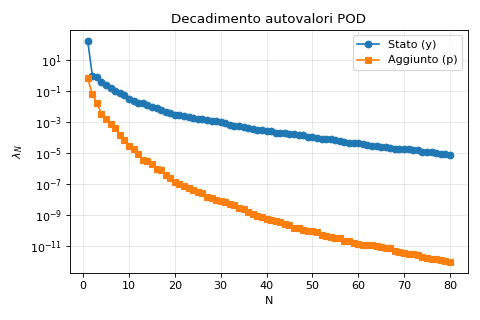

In [8]:
INNER_PRODUCT = 'seminorm'  # 'seminorm' (solo A_diff) o 'full' (A_diff + M_full)
ENERGY_THRESHOLD = 1-1e-6   # N scelto automaticamente in base a questa soglia
POD_PATH = os.path.join(SNAPSHOTS_DIR, 'test1_pod.npz')

!python -m src.rom.train_pod \
    --config {CONFIG_PATH} \
    --snapshots {SNAPSHOTS_PATH} \
    --inner-product {INNER_PRODUCT} \
    --energy-threshold {ENERGY_THRESHOLD} \
    --output {POD_PATH} \
    --plot

import tempfile, os as _os
from IPython.display import Image
Image(_os.path.join(tempfile.gettempdir(), 'pod_eigenvalue_decay.png'))

### 3.2 Controllo (PODNN)

`u` non e' un campo di dominio come `y` - e' una traccia 1D sul bordo dove il controllo puo' essere attivo, mascherata a zero fuori Gamma_C (per definizione: `u = dy/dn = 0` su Gamma_N). La POD si fa su questa traccia (prodotto scalare euclideo), poi una piccola FFNN impara `mu -> coefficienti proiettati` (pattern PODNN, `Lab9/PODnn.ipynb` del prof).

In [ ]:
CONTROL_POD_PATH = os.path.join(SNAPSHOTS_DIR, 'test1_control_pod.npz')
CONTROL_ENERGY_THRESHOLD = 1 - 1e-6   # N scelto automaticamente in base a questa soglia
CONTROL_MAX_MODES = 50                 # tetto massimo, anche se la soglia non e' raggiunta

!python -m src.rom.build_control_pod \
    --config {CONFIG_PATH} \
    --snapshots {SNAPSHOTS_PATH} \
    --energy-threshold {CONTROL_ENERGY_THRESHOLD} \
    --max-modes {CONTROL_MAX_MODES} \
    --output {CONTROL_POD_PATH} \
    --plot

import tempfile, os as _os
from IPython.display import Image
Image(_os.path.join(tempfile.gettempdir(), 'control_pod_eigenvalue_decay.png'))

Errore di ricostruzione della **sola base POD** (proiezione di Galerkin, senza rete) sul test set — isola quanto e' brava la base da quanto impara bene la rete:

In [ ]:
!python -m src.rom.evaluate_control_pod \
    --config {CONFIG_PATH} \
    --pod-model {CONTROL_POD_PATH} \
    --test-snapshots {TEST_SNAPSHOTS_PATH}

Training della rete (parametri modificabili qui, indipendenti dalla POD sopra):

In [12]:
CONTROL_NN_PATH = os.path.join(SNAPSHOTS_DIR, 'test1_control_nn.pt')
EPOCHS = 50000
LR = 1e-3

!python -m src.rom.train_control_nn \
    --pod-model {CONTROL_POD_PATH} \
    --epochs {EPOCHS} \
    --lr {LR} \
    --output {CONTROL_NN_PATH}

Caricamento base POD da data/snapshots/test1_control_pod.npz ...
Training FFNN mu -> coefficienti POD(u) ...
  epoch 2000  loss 4.547119e-01  lr 1.0e-03
  epoch 4000  loss 2.742738e-01  lr 1.0e-03
  epoch 6000  loss 1.122628e+00  lr 1.0e-03
  epoch 8000  loss 2.482008e-01  lr 1.0e-03
  epoch 10000  loss 1.258275e-01  lr 1.0e-03
  epoch 12000  loss 5.104915e-01  lr 1.0e-03
  epoch 14000  loss 3.505889e-01  lr 1.0e-03
  epoch 16000  loss 1.510327e-01  lr 1.0e-03
  epoch 18000  loss 1.300863e-01  lr 1.0e-03
  epoch 20000  loss 1.170554e-01  lr 1.0e-03
  epoch 22000  loss 1.034389e-01  lr 1.0e-03
  epoch 24000  loss 9.576029e-02  lr 1.0e-03
  epoch 26000  loss 2.766113e-01  lr 1.0e-04
  epoch 28000  loss 2.616522e-01  lr 1.0e-04
  epoch 30000  loss 1.003211e-01  lr 1.0e-04
  epoch 32000  loss 9.285296e-02  lr 1.0e-04
  epoch 34000  loss 8.899174e-02  lr 1.0e-04
  epoch 36000  loss 8.661317e-02  lr 1.0e-04
  epoch 38000  loss 8.496487e-02  lr 1.0e-04
  epoch 40000  loss 8.366880e-02  lr 1.0

In [15]:
!python -m src.rom.evaluate_control_podnn \
    --config {CONFIG_PATH} \
    --pod-model {CONTROL_POD_PATH} \
    --weights {CONTROL_NN_PATH} \
    --test-snapshots {TEST_SNAPSHOTS_PATH}

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Caricamento base POD da data/snapshots/test1_control_pod.npz ...
Caricamento pesi rete da data/snapshots/test1_control_nn.pt ...
Caricamento test set da data/snapshots/test1_test150.npz ...
Estrazione traccia di controllo vera (test set) ...
Predizione con la PODNN ...
Errore relativo medio: 7.7567e-01
Errore relativo mediano: 6.3060e-01
Errore relativo max: 5.4430e+00


## 4. GNN

*(da aggiungere)*

## 5. Autoencoder

*(da aggiungere)*